# The steady-state branch: reduction, then simulation

One declared model serves both branches. The dynamic transforms
(discretization, the terminal segment, the control profiles) build the
horizon problem; the steady branch instead collapses the same declarations
to a single point. `drto.dynamic_to_steady_state` (feature 005) performs
the reduction: every derivative reference replaced by zero, time collapsed,
the initial condition and terminal pieces removed. `drto.steady_state_simulation`
(feature 008) composes that reduction, fixes the declared controls, and
installs the zero objective: the square problem whose solution is the
equilibrium under the given inputs.

The model is the Hicks-Ray CSTR from [`models/hicks.py`](models/hicks.py).
Its declared setpoints are a true fixed point of the dynamics, so simulating
at the reference inputs must land exactly on the reference steady state:
the model-consistency check the reduction makes automatic.

## The reduction: the declared model, collapsed

In [1]:
import pyomo.environ as pyo
import drto
from models.hicks import hicks

m = hicks(N=5)
ss = pyo.TransformationFactory("drto.dynamic_to_steady_state").create_using(m)
drto.info(ss)

states,"zc (free), zt (free)"
dynamics,0 == (1 - zc)/(u2sf*v2) - k0*zc*exp(- ea/zt)
dynamics,0 == (ztf - zt)/(u2sf*v2) + k0*zc*exp(- ea/zt) - a0*u1sf*v1*(zt - ztcw)
controls,"v1 (piecewise_constant, free), v2 (piecewise_constant, free)"
tracking stage cost,cost == 10*(zc - zc_ss)**2 + 2*(zt - zt_ss)**2 + (v1 - v1_ss)**2 + 0.5*(v2 - v2_ss)**2
steady-state targets,"zc_ss (of zc), zt_ss (of zt)"
steady-state control targets,"v1_ss (of v1), v2_ss (of v2)"


## Simulation at the reference inputs

In [2]:
sim = pyo.TransformationFactory("drto.steady_state_simulation").create_using(
    m, controls={m.v1: 0.57828, m.v2: 0.49989}
)
pyo.SolverFactory("pounce").solve(sim, tee=True)
print(f"equilibrium: zc = {pyo.value(sim.zc):.5f} (target 0.64160), "
      f"zt = {pyo.value(sim.zt):.5f} (target 0.53870)")

pounce: wrote C:\Users\Devin\AppData\Local\Temp\tmpvyyyfpsn.pyomo.sol


********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpvyyyfpsn.pyomo.nl...
Parsed 3 vars, 3 

equilibrium: zc = 0.64160 (target 0.64160), zt = 0.53870 (target 0.53870)


## The equilibrium locus

The same one-line simulation, swept over the coolant flow at the reference
residence time: the map of resting points the controller moves between.

model.name="unknown";
    - termination condition: infeasible
    - message from solver: POUNCE 0.8.0\x3a InfeasibleProblemDetected


model.name="unknown";
    - termination condition: infeasible
    - message from solver: POUNCE 0.8.0\x3a InfeasibleProblemDetected


model.name="unknown";
    - termination condition: infeasible
    - message from solver: POUNCE 0.8.0\x3a InfeasibleProblemDetected


model.name="unknown";
    - termination condition: infeasible
    - message from solver: POUNCE 0.8.0\x3a InfeasibleProblemDetected


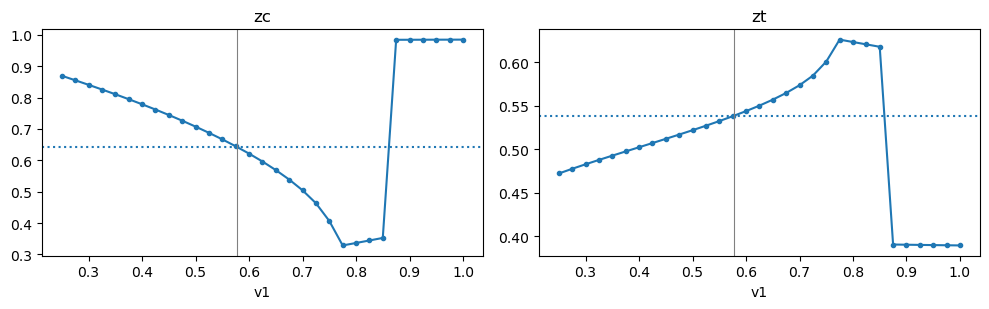

In [3]:
import matplotlib.pyplot as plt
import numpy as np

v1_grid = np.linspace(0.25, 1.0, 31)
zc_eq, zt_eq = [], []
solver = pyo.SolverFactory("pounce")
for v1 in v1_grid:
    sim = pyo.TransformationFactory("drto.steady_state_simulation").create_using(
        m, controls={m.v1: float(v1), m.v2: 0.49989}
    )
    solver.solve(sim)
    zc_eq.append(pyo.value(sim.zc))
    zt_eq.append(pyo.value(sim.zt))

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.2), sharex=True)
for ax, vals, name, ref in zip(axes, (zc_eq, zt_eq), ("zc", "zt"), (0.6416, 0.5387)):
    ax.plot(v1_grid, vals, "o-", color="C0", markersize=3)
    ax.axhline(ref, color="C0", linestyle=":")
    ax.axvline(0.57828, color="grey", linewidth=0.8)
    ax.set_title(name)
    ax.set_xlabel("v1")
fig.tight_layout()